In [1]:
import sys
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import time

sys.path.append('..')
from stattool.empirical_design import check_aa
from stattool.plot_tool import plot_cdf
from scipy.stats import norm, ttest_ind
from stattool import deltamethod
from stattool.theoretical_design import get_parameter_size
from stattool.experiment_tool import conduct_test, format_results

In [2]:
df = pd.read_parquet('../dataset/prepared_trips.parquet')

# Primary analysis

In [7]:
df.head()

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,trip_id,completed_by,assigned,complete_time,day_of_week,hour_of_day
0,HV0003,B03404,B03404,2024-01-01 00:21:47,2024-01-01 00:25:06,2024-01-01 00:28:08,2024-01-01 01:05:39,161,158,2.83,...,N,N,N,N,4392ca40-a9d7-4296-919f-436dd4a08985,None,False,1999-01-01,Monday,0
1,HV0003,B03404,B03404,2024-01-01 00:10:56,2024-01-01 00:11:08,2024-01-01 00:12:53,2024-01-01 00:20:05,137,79,1.57,...,N,N,N,N,27806568-cf51-4afb-b016-feca1d574618,None,False,1999-01-01,Monday,0
2,HV0003,B03404,B03404,2024-01-01 00:20:04,2024-01-01 00:21:51,2024-01-01 00:23:05,2024-01-01 00:35:16,79,186,1.98,...,N,N,N,N,33c84571-f964-4373-ab1a-84c01d272b0f,None,False,1999-01-01,Monday,0
3,HV0003,B03404,B03404,2024-01-01 00:35:46,2024-01-01 00:39:59,2024-01-01 00:41:04,2024-01-01 00:56:34,234,148,1.99,...,N,N,N,N,17c02318-f3a4-464a-83d0-221c1664cb14,None,False,1999-01-01,Monday,0
4,HV0003,B03404,B03404,2024-01-01 00:48:19,2024-01-01 00:56:23,2024-01-01 00:57:21,2024-01-01 01:10:02,148,97,2.65,...,N,N,N,N,42c4823a-9308-418b-97a1-64a772d6d5be,None,False,1999-01-01,Monday,0


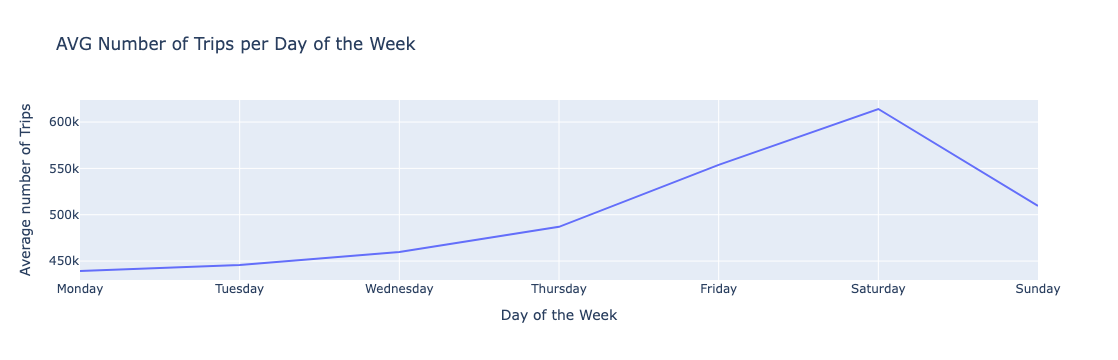

In [14]:
df['request_datetime'] = pd.to_datetime(df['request_datetime'])
df['request_date'] = pd.to_datetime(df['request_datetime'].dt.date)
df['day_of_week'] = df['request_date'].dt.day_name()

trips_per_day = df.groupby(['request_date', 'day_of_week'])['trip_id'].count().reset_index()
trips_per_day = trips_per_day.groupby(['day_of_week'])['trip_id'].mean().reindex(['Monday', 
                                                                                  'Tuesday', 
                                                                                  'Wednesday', 
                                                                                  'Thursday', 
                                                                                  'Friday',
                                                                                  'Saturday', 
                                                                                  'Sunday'])

fig = px.line(
    x=trips_per_day.index,
    y=trips_per_day.values,
    labels={'x': 'Day of the Week', 'y': 'Average number of Trips'},
    title='AVG Number of Trips per Day of the Week'
)
fig.show()

In [ ]:
df['hour_of_day'] = df['pickup_datetime'].dt.hour

trips_per_hour = df.groupby(['request_date', 'hour_of_day'])['trip_id'].count().reset_index()
trips_per_hour = df.groupby(['hour_of_day'])['trip_id'].mean()

fig = px.line(
    x=trips_per_hour.index,
    y=trips_per_hour.values,
    labels={'x': 'Hour of the Day', 'y': 'Number of Trips'},
    title='Number of Trips per Hour of the Day'
)
fig.show()



office workers patterns 
lets check if it differs by day 

In [ ]:
df['hour_of_day'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.day_name()

grouped = df.groupby(['request_date', 'hour_of_day', 'day_of_week'])['trip_id'].count().reset_index()
grouped = grouped.groupby('hour_of_day', 'day_of_week')['trip_id'].mean()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
grouped['day_of_week'] = pd.Categorical(grouped['day_of_week'], categories=day_order, ordered=True)
grouped = grouped.sort_values(['day_of_week', 'hour_of_day'])

fig = px.line(
    grouped,
    x='hour_of_day',
    y='trip_count',
    color='day_of_week',
    labels={'hour_of_day': 'Hour of the Day', 'trip_count': 'Number of Trips'},
    title='Number of Trips per Hour by Day of the Week'
)
fig.show()


as expected on working days (mon-friday) peak in the morning, lower number of trips during nights
and on sat and sun vice versa

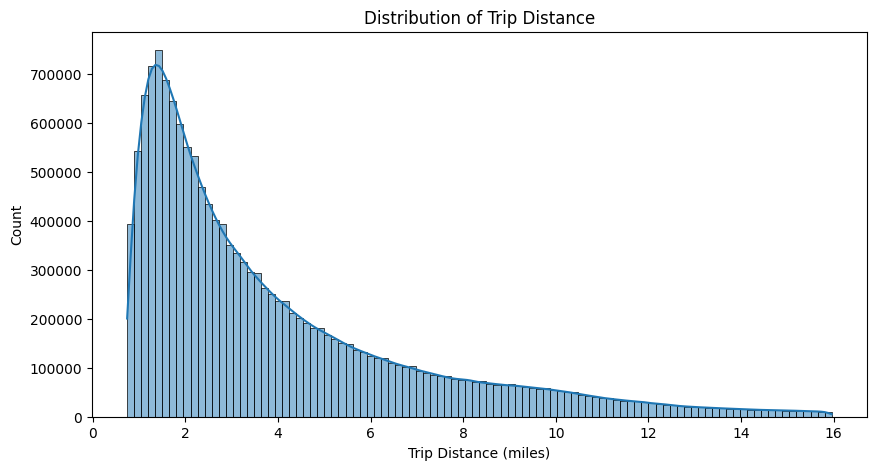

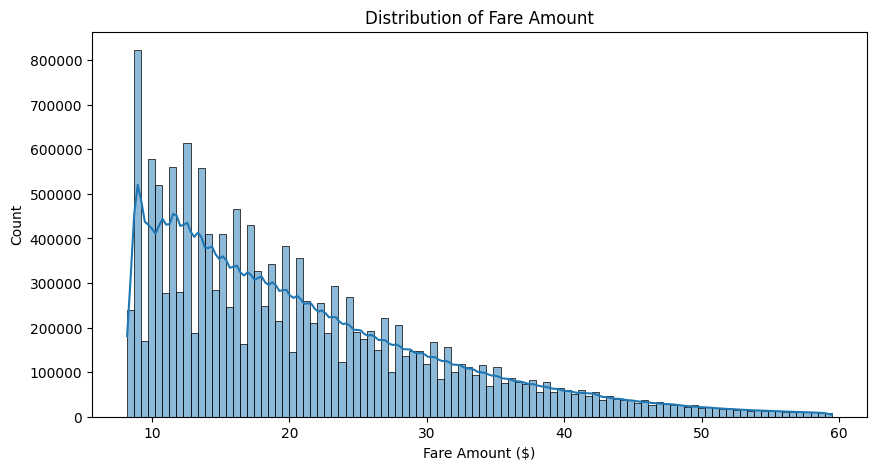

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['trip_miles'], bins=100, kde=True)
plt.title('Distribution of Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df['base_passenger_fare'], bins=100, kde=True)
plt.title('Distribution of Fare Amount')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Count')
plt.show()



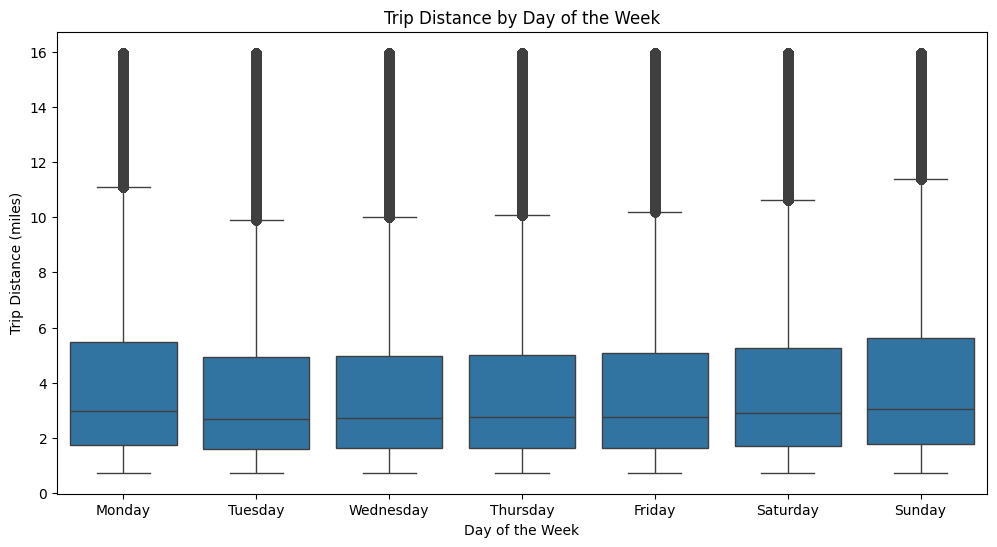

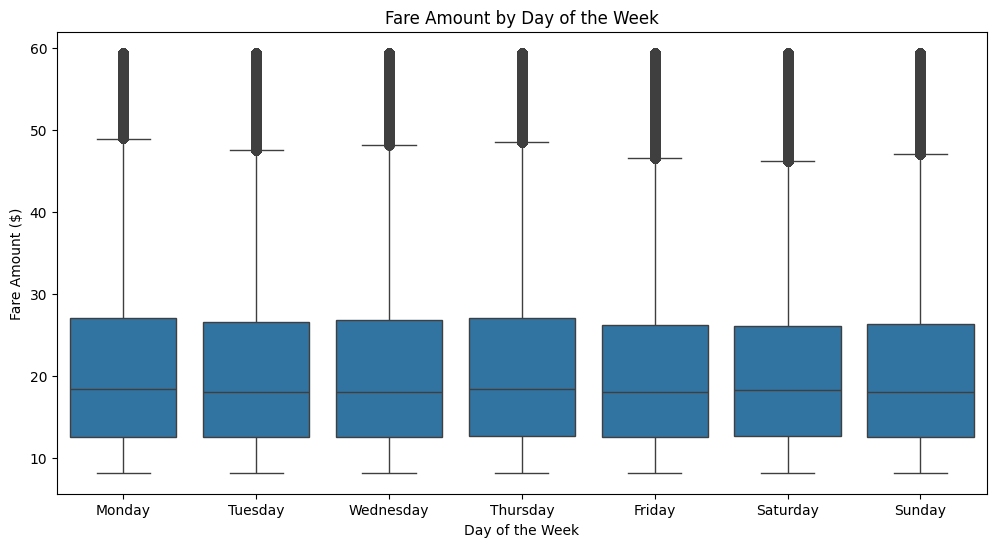

In [7]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='day_of_week', y='trip_miles', order=order)
plt.title('Trip Distance by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Trip Distance (miles)')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='day_of_week', y='base_passenger_fare', order=order)
plt.title('Fare Amount by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Fare Amount ($)')
plt.show()



KeyboardInterrupt



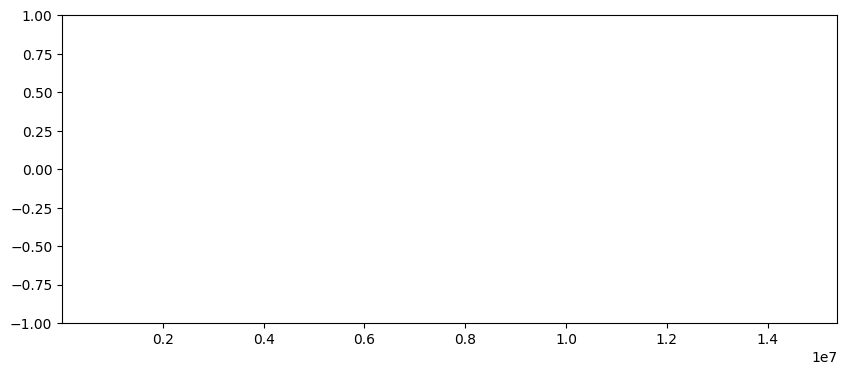

In [8]:
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
autocorrelation_plot(df['trip_miles'].dropna())
plt.title('Autocorrelation of Trip Distance')
plt.show()

plt.figure(figsize=(10, 4))
autocorrelation_plot(df['base_passenger_fare'].dropna())
plt.title('Autocorrelation of Fare Amount')
plt.show()


In [ ]:
df['hour_of_day'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek

fig, ax = plt.subplots(1, 1, figsize=(20, 8))

corr = df[['PULocationID', 'DOLocationID', 
           'trip_miles', 'trip_time', 'base_passenger_fare', 
           'congestion_surcharge', 'driver_pay',
           'hour_of_day', 'day_of_week']].corr()

sns.heatmap(corr, 
            xticklabels=corr.columns,
            yticklabels=corr.columns, 
            annot=True,
            cmap='coolwarm', 
            ax=ax)
plt.title('Correlation Matrix')
plt.show()


# Preparing Data

In [2]:
def get_trad_df(completed_cars_file, number, co2_per_km=4.8, agg=2):
    date_range = pd.date_range(
        start="2024-01-01 00:00:00", 
        end="2024-02-01 00:00:00", 
        freq=f"{agg}min"
    )
    on_line_cars = pd.DataFrame({"agg": date_range})
    on_line_cars["hour"] = on_line_cars["agg"].dt.hour
    on_line_cars["on_line_time"] = on_line_cars["hour"].apply(
    lambda x: 840 * number if (x < 21) and (x >= 6) else 0
    )
    
    trips_table = pd.read_parquet(f'../results/{completed_cars_file}')
    
    trips_table['agg'] = trips_table['request_datetime'].dt.floor(f"{agg}min")
    trips_table['net_revenue'] = trips_table['base_passenger_fare'] + trips_table['airport_fee'] - trips_table['driver_pay']
    trips_table['revenue'] = trips_table['base_passenger_fare'] + trips_table['airport_fee']

    metrics = trips_table.pivot_table(index='agg', 
                            columns='assigned', 
                            values='trip_id', 
                            aggfunc='count',
                            fill_value=0).reset_index().rename(columns={False:'missed_trips', True:'completed_trips'})
    
    assigned = trips_table[trips_table['assigned'] == True]
    assigned_metrics = assigned.groupby('agg')[['net_revenue', 'revenue', 'trip_time', 'trip_miles']].sum().reset_index()\
                    .rename(columns={'trip_time': 'time_with_passenger'})

    metrics = metrics.merge(assigned_metrics, on='agg', how='left')
    
    metrics = metrics.merge(on_line_cars, on='agg', how='left')
    
    metrics['cnt_trips'] = metrics['completed_trips'] + metrics['missed_trips']
    metrics['co2_emissions'] = co2_per_km * metrics['trip_miles'] * 0.62 # 06 miles = 1 km 

    metrics['default'] = 1

    metrics[['missed_trips', 'completed_trips', 'net_revenue', 'revenue',
       'time_with_passenger', 'trip_miles', 'hour', 'on_line_time',
       'cnt_trips', 'co2_emissions']] = metrics[['missed_trips', 'completed_trips', 'net_revenue', 'revenue',
       'time_with_passenger', 'trip_miles', 'hour', 'on_line_time',
       'cnt_trips', 'co2_emissions']].fillna(0)

    return metrics
    

In [3]:
def get_df_from_files(on_line_cars_files, completed_cars_file, co2_per_km = 0.4, agg=3, include_driver_pay=True):
    on_line_cars = pd.read_parquet(f'../results/{on_line_cars_files}')
    on_line_cars['agg'] = pd.to_datetime(on_line_cars['timestamp']).dt.floor(f'{agg}min')
    
    trips_table = pd.read_parquet(f'../results/{completed_cars_file}')
    
    trips_table['agg'] = trips_table['request_datetime'].dt.floor(f'{agg}min')
    trips_table['net_revenue'] = trips_table['base_passenger_fare'] + trips_table['airport_fee']
    if include_driver_pay:
        trips_table['net_revenue'] -= trips_table['driver_pay']
    trips_table['revenue'] = trips_table['base_passenger_fare'] + trips_table['airport_fee']

    metrics = trips_table.pivot_table(index='agg', 
                            columns='assigned', 
                            values='trip_id', 
                            aggfunc='count',
                            fill_value=0).reset_index().rename(columns={False:'missed_trips', True:'completed_trips'})
    
    assigned = trips_table[trips_table['assigned'] == True]
    metrics_assigned = assigned.groupby('agg')[['net_revenue', 'revenue', 'trip_time', 'trip_miles']].sum().reset_index()\
                    .rename(columns={'trip_time': 'time_with_passenger'})

    metrics = metrics.merge(metrics_assigned, on='agg', how='left')
    
    aggregated_on_line_cars = on_line_cars.groupby(['agg', 'car_id'])['timestamp'].agg(['min', 'max'])
    aggregated_on_line_cars['on_line_time'] = (pd.to_datetime(aggregated_on_line_cars['max']) - pd.to_datetime(aggregated_on_line_cars['min']))\
                                .dt.total_seconds()
    metrics = metrics.merge(aggregated_on_line_cars.groupby(['agg'])['on_line_time'].sum().reset_index(), on='agg', how='left')
    
    metrics['cnt_trips'] = metrics['completed_trips'] + metrics['missed_trips']
    metrics['co2_emissions'] = co2_per_km * metrics['trip_miles'] * 0.62 # 06 miles = 1 km 

    metrics['default'] = 1

    metrics[['missed_trips', 'completed_trips', 'net_revenue', 'revenue',
       'time_with_passenger', 'trip_miles', 'on_line_time',
       'cnt_trips', 'co2_emissions']] = metrics[['missed_trips', 'completed_trips', 'net_revenue', 'revenue',
       'time_with_passenger', 'trip_miles', 'on_line_time',
       'cnt_trips', 'co2_emissions']].fillna(0)

    return metrics

In [4]:
fleet_sizes = [100, 500, 1000, 2000, 3500]

df = pd.DataFrame()

for fleet in fleet_sizes:
    saev = get_df_from_files(f'saev_online_cars_day_{fleet}.parquet', f'saev_completed_trips_day_{fleet}.parquet', include_driver_pay=False)
    trad = get_trad_df(f'trad_completed_trips_day_{fleet}.parquet', fleet)
    hailing = get_df_from_files(f'hailing_platform_online_cars_day_{fleet}.parquet', f'hailing_platform_completed_trips_day_{fleet}.parquet', co2_per_km=4.8)

    saev['group'] = 'saev'
    trad['group'] = 'trad'
    hailing['group'] = 'hailing'

    res = pd.concat([saev, trad, hailing])
    res['fleet_size'] = fleet

    df = pd.concat([res, df], ignore_index=True)
    print('Downloaded fleet_size', fleet)

Downloaded fleet_size {100}
Downloaded fleet_size {500}
Downloaded fleet_size {1000}
Downloaded fleet_size {2000}
Downloaded fleet_size {3500}


In [5]:
# quick sanity check 
df.groupby(['group', 'fleet_size'])['net_revenue'].median()

group    fleet_size
hailing  100             50.090
         500            256.580
         1000           499.600
         2000           979.515
         3500          1210.425
saev     100            182.790
         500            920.270
         1000          1804.300
         2000          3521.480
         3500          4740.290
trad     100             19.260
         500            138.620
         1000           295.540
         2000           583.690
         3500           691.160
Name: net_revenue, dtype: float64

In [53]:
df[df['net_revenue'] < 0 ]

,Unnamed: 0.1,Unnamed: 0,agg,missed_trips,completed_trips,net_revenue,revenue,time_with_passenger,trip_miles,on_line_time,cnt_trips,co2_emissions,default,group,hour,fleet_size,day_of_week,hour_of_day
223328,223328,223328,2024-01-01 06:34:00,79,4,-7.26,61.18,2853.0,8.967,84000.0,83,26.685792,1,trad,6.0,100,Monday,6
223386,223386,223386,2024-01-01 08:30:00,63,5,-2.84,118.00,5769.0,28.641,84000.0,68,85.235616,1,trad,8.0,100,Monday,8
224346,224346,224346,2024-01-02 16:30:00,176,5,-7.34,81.60,5016.0,17.611,84000.0,181,52.410336,1,trad,16.0,100,Tuesday,16
224349,224349,224349,2024-01-02 16:36:00,175,7,-4.19,85.47,6382.0,16.122,84000.0,182,47.979072,1,trad,16.0,100,Tuesday,16
225032,225032,225032,2024-01-03 15:22:00,146,3,-0.31,61.47,4447.0,13.050,84000.0,149,38.836800,1,trad,15.0,100,Wednesday,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254910,254910,254910,2024-01-20 17:18:00,271,7,-7.69,144.31,10475.0,33.855,12000.0,278,162.504000,1,hailing,NaN,100,Saturday,17
254926,254926,254926,2024-01-20 18:06:00,329,6,-1.72,86.26,5601.0,13.440,12000.0,335,64.512000,1,hailing,NaN,100,Saturday,18
256932,256932,256932,2024-01-24 22:24:00,239,8,-0.09,101.13,6653.0,22.190,12000.0,247,106.512000,1,hailing,NaN,100,Wednesday,22
258272,258272,258272,2024-01-27 17:24:00,221,3,-1.89,54.98,3505.0,17.300,12000.0,224,83.040000,1,hailing,NaN,100,Saturday,17


In [6]:
df.columns

Index(['agg', 'missed_trips', 'completed_trips', 'net_revenue', 'revenue',
       'time_with_passenger', 'trip_miles', 'on_line_time', 'cnt_trips',
       'co2_emissions', 'default', 'group', 'hour', 'fleet_size'],
      dtype='object')

In [17]:
df.to_csv('metric_results.csv')

In [18]:
df = pd.read_csv('metric_results.csv', index_col=False)

# Main Analysis

## Economic analysis

In [19]:
df['agg'] = pd.to_datetime(df['agg'])
df['day_of_week'] = df['agg'].dt.day_name()
df['hour_of_day'] = df['agg'].dt.hour

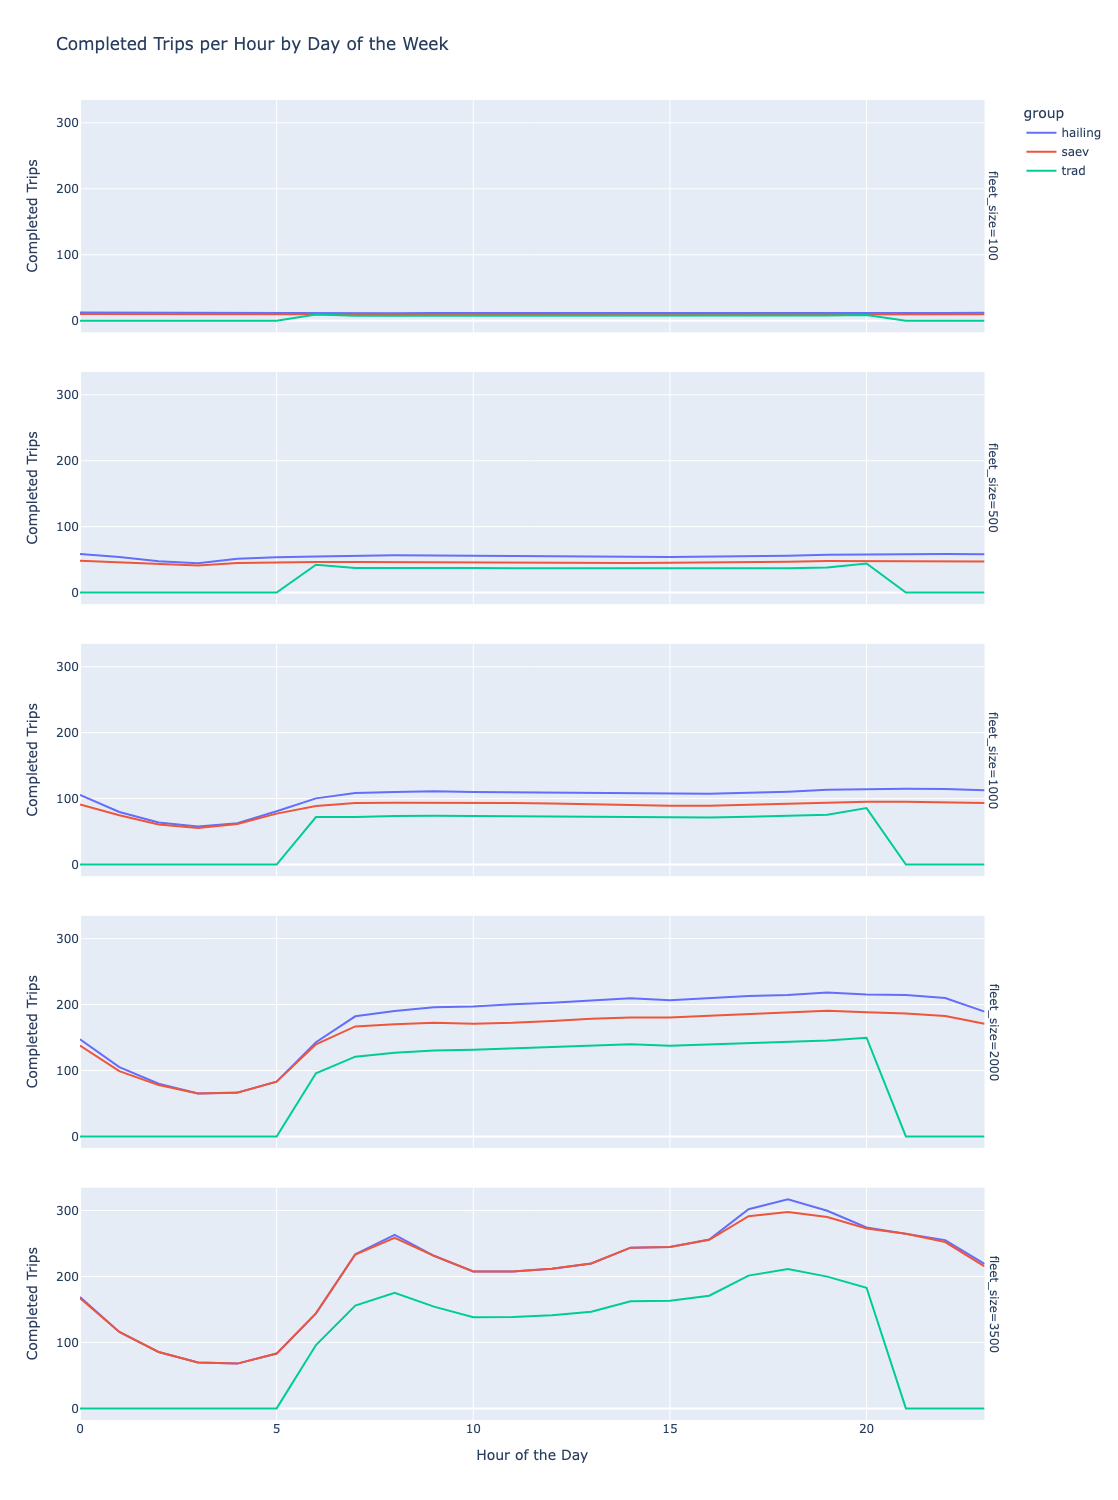

In [20]:
grouped = df.groupby(['hour_of_day', 'fleet_size', 'group'])['completed_trips'].mean().reset_index()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
grouped = grouped.sort_values(['hour_of_day', 'fleet_size', 'group'])

fig = px.line(
    grouped,
    x='hour_of_day',
    y='completed_trips',
    color='group',
    facet_row='fleet_size',
    labels={'hour_of_day': 'Hour of the Day', 'completed_trips': 'Completed Trips'},
    title='Completed Trips per Hour by Day of the Week'
)
fig.update_layout(
    height=1500,
    width=1100
)
fig.show()

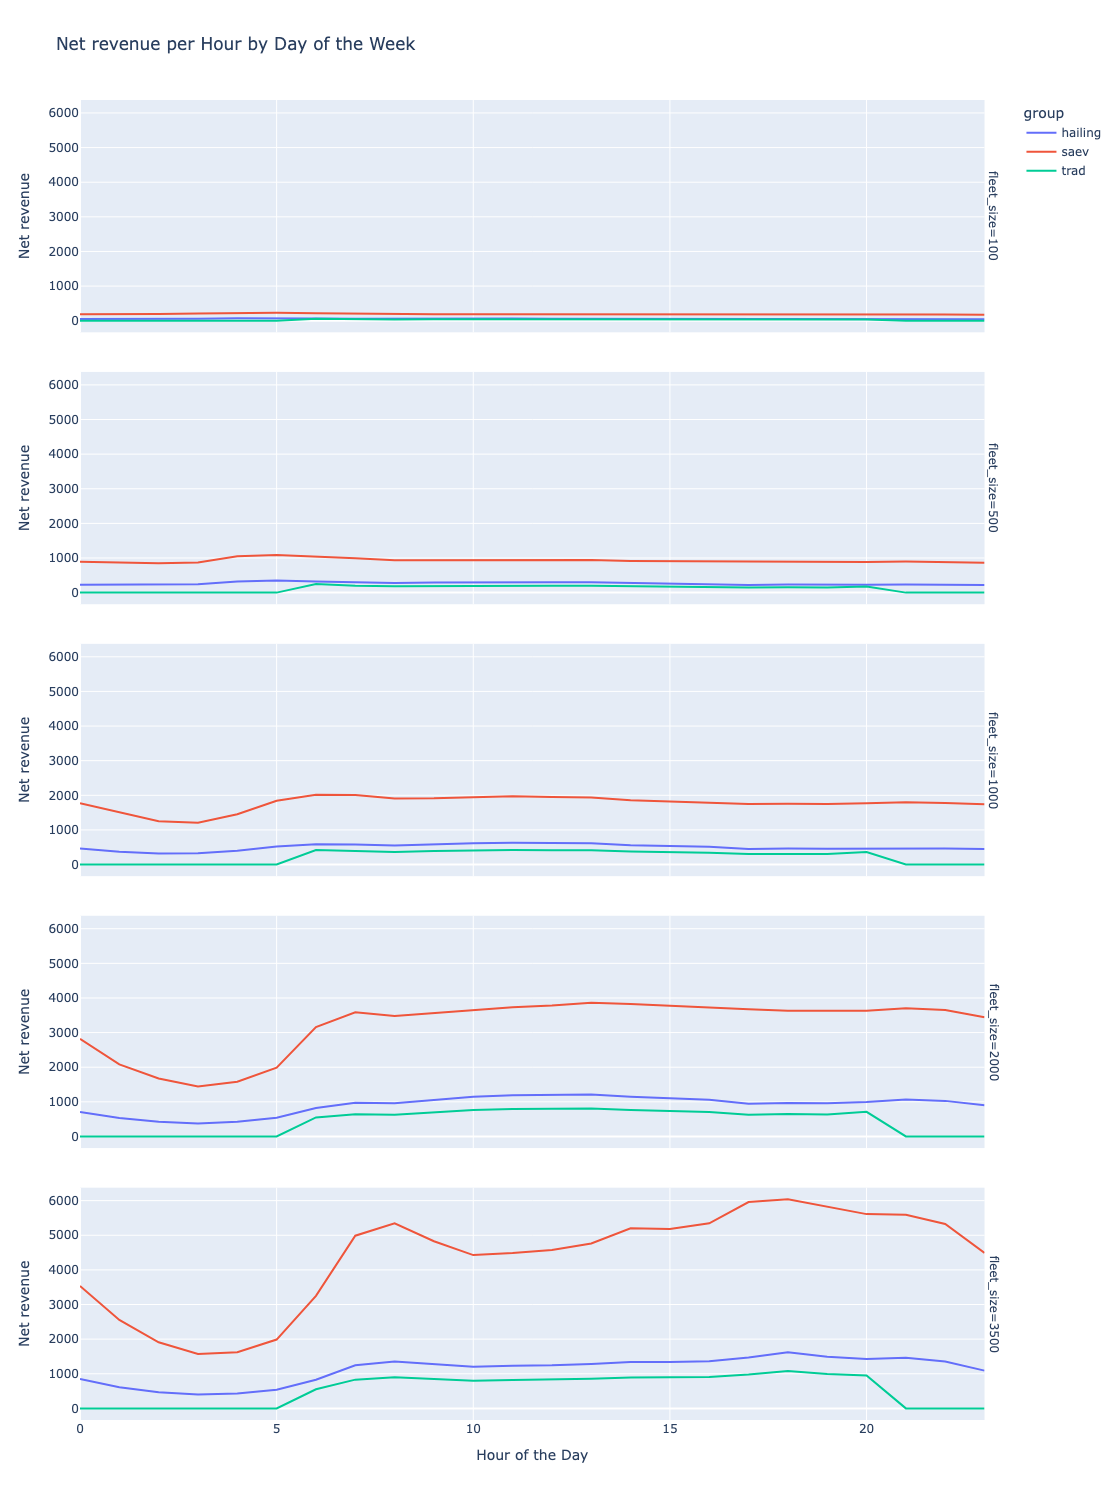

In [21]:
grouped = df.groupby(['hour_of_day', 'fleet_size', 'group'])['net_revenue'].mean().reset_index()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
grouped = grouped.sort_values(['hour_of_day', 'fleet_size', 'group'])

fig = px.line(
    grouped,
    x='hour_of_day',
    y='net_revenue',
    color='group',
    facet_row='fleet_size',
    labels={'hour_of_day': 'Hour of the Day', 'net_revenue': 'Net revenue'},
    title='Net revenue per Hour by Day of the Week'
)
fig.update_layout(
    height=1500,
    width=1100
)
fig.show()

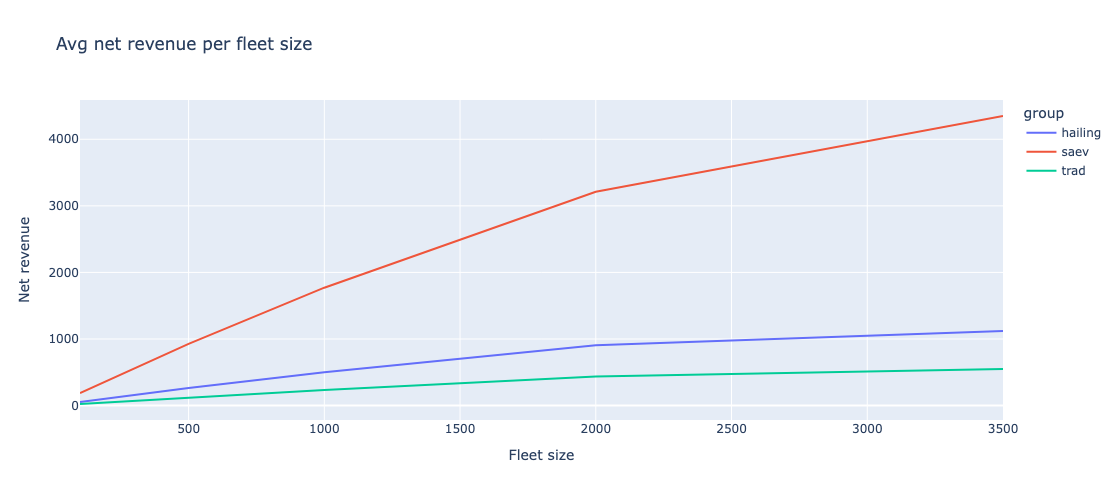

In [22]:
grouped = df.groupby(['fleet_size', 'group'])[['net_revenue', 'completed_trips']].mean().reset_index()

fig = px.line(
        grouped,
        x='fleet_size',
        y='net_revenue',
        color='group',
        title='Avg net revenue per fleet size',
        labels={'fleet_size': 'Fleet size', 'net_revenue': 'Net revenue'}
)

fig.update_layout(
    height=500,
    width=1000)

fig.show()

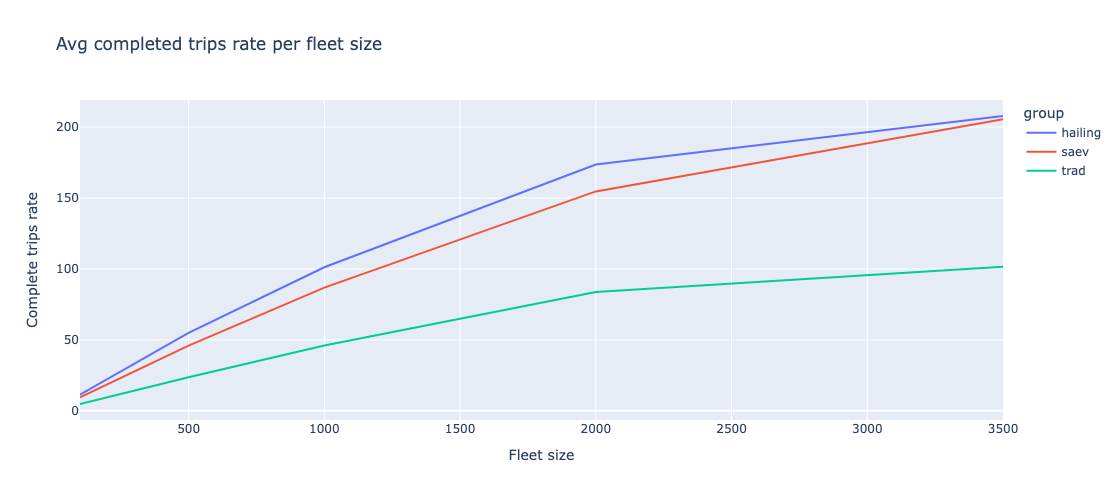

In [23]:
fig = px.line(
        grouped,
        x='fleet_size',
        y='completed_trips',
        color='group',
        title='Avg completed trips rate per fleet size',
        labels={'fleet_size': 'Fleet size', 'completed_trips': 'Complete trips rate'},
)

fig.update_layout(
    height=500,
    width=1000)

fig.show()

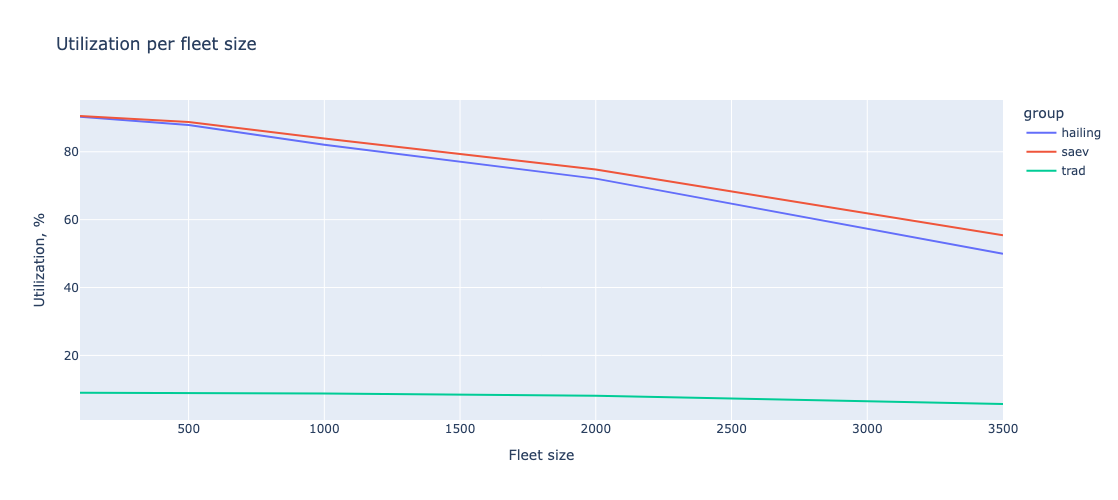

In [24]:
grouped = df.groupby(['fleet_size', 'group'])[['on_line_time', 'time_with_passenger']].sum().reset_index()
grouped['utilization'] = 100.0 * grouped['time_with_passenger'] / grouped['on_line_time']

fig = px.line(
        grouped,
        x='fleet_size',
        y='utilization',
        color='group',
        title='Utilization per fleet size',
        labels={'fleet_size': 'Fleet size', 'utilization': 'Utilization, %'}
)

fig.update_layout(
    height=500,
    width=1000)

fig.show()

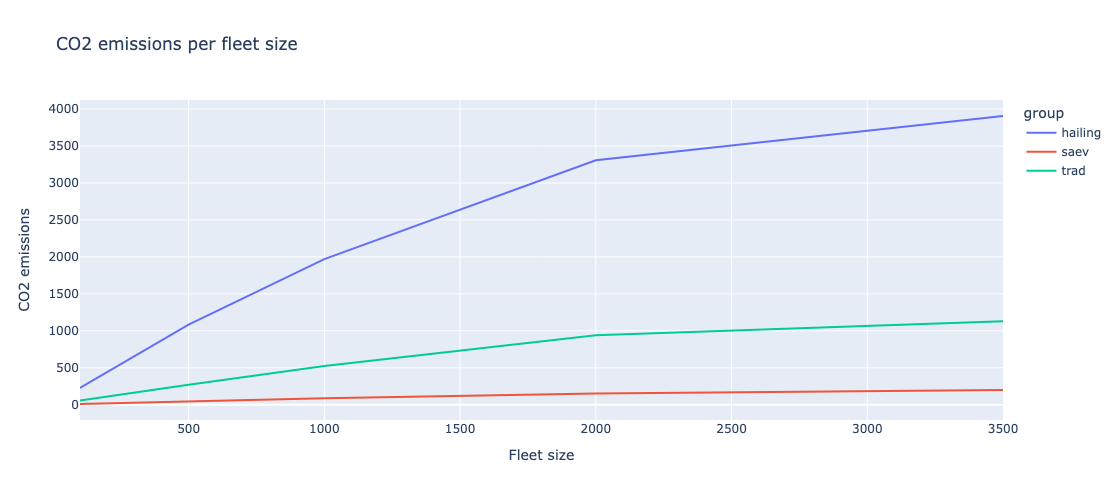

In [25]:
grouped = df.groupby(['fleet_size', 'group'])[['co2_emissions']].mean().reset_index()

fig = px.line(
        grouped,
        x='fleet_size',
        y='co2_emissions',
        color='group',
        title='CO2 emissions per fleet size',
        labels={'fleet_size': 'Fleet size', 'co2_emissions': 'CO2 emissions'}
)

fig.update_layout(
    height=500,
    width=1000)

fig.show()

# Hypothesis testing

In [31]:
combinations = [('trad', 'saev'), ('hailing', 'saev')]

In [32]:
fleet_sizes = [100, 500, 1000, 2000, 3500]

metric_description = {'co2_emissions': {'nominator': 'co2_emissions', 'denominator': 'default'},
                     'net_revenue': {'nominator': 'net_revenue', 'denominator': 'default'},
                     'utilization': {'nominator': 'time_with_passenger', 'denominator': 'on_line_time'},
                     'completed_trips': {'nominator': 'completed_trips', 'denominator': 'default'},
                     }

tag_names = list(df['group'].unique())

results = pd.DataFrame(
        columns=["metric_name", "group", "metric_value_left", "metric_value_right", "lift", "pval", "fleet_size"]
    )

for fleet in fleet_sizes:
    to_conduct = df[df['fleet_size'] == fleet]
    for metric, desc in metric_description.items():
        result = conduct_test(data=to_conduct,
                     nominator=desc['nominator'],
                     metric_name=metric,
                     combination=combinations,
                     tag_names=tag_names,
                     denominator=desc['denominator'],
                     alpha=0.01
                    )
        result['fleet_size'] = fleet
        results = pd.concat([results, result], axis=0)


/Users/enbelodedova/Documents/diploma.simulation/analysis/../stattool/experiment_tool.py:74: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/var/folders/xs/_0l9xrzj3tz9bsyngdnyxmhr0000gn/T/ipykernel_9115/3781768733.py:27: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/Users/enbelodedova/Documents/diploma.simulation/analysis/../stattool/experiment_tool.py:74: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer

In [33]:
results

,metric_name,group,metric_value_left,metric_value_right,lift,pval,fleet_size,is_reject
0,co2_emissions,hailing vs saev,226.724713,9.705676,-95.719180,0.000000e+00,100,True
0,co2_emissions,trad vs saev,55.463503,9.705676,-82.500788,0.000000e+00,100,True
0,net_revenue,hailing vs saev,53.747399,188.741191,251.163395,0.000000e+00,100,True
0,net_revenue,trad vs saev,23.292201,188.741191,710.319248,0.000000e+00,100,True
0,utilization,hailing vs saev,0.903251,0.905371,0.234799,5.569277e-01,100,False
0,utilization,trad vs saev,0.089855,0.905371,907.587066,0.000000e+00,100,True
0,completed_trips,hailing vs saev,11.495462,9.484706,-17.491740,0.000000e+00,100,True
0,completed_trips,trad vs saev,4.826514,9.484706,96.512566,0.000000e+00,100,True
0,co2_emissions,hailing vs saev,1084.230955,46.923447,-95.672191,0.000000e+00,500,True
0,co2_emissions,trad vs saev,271.345117,46.923447,-82.707097,0.000000e+00,500,True


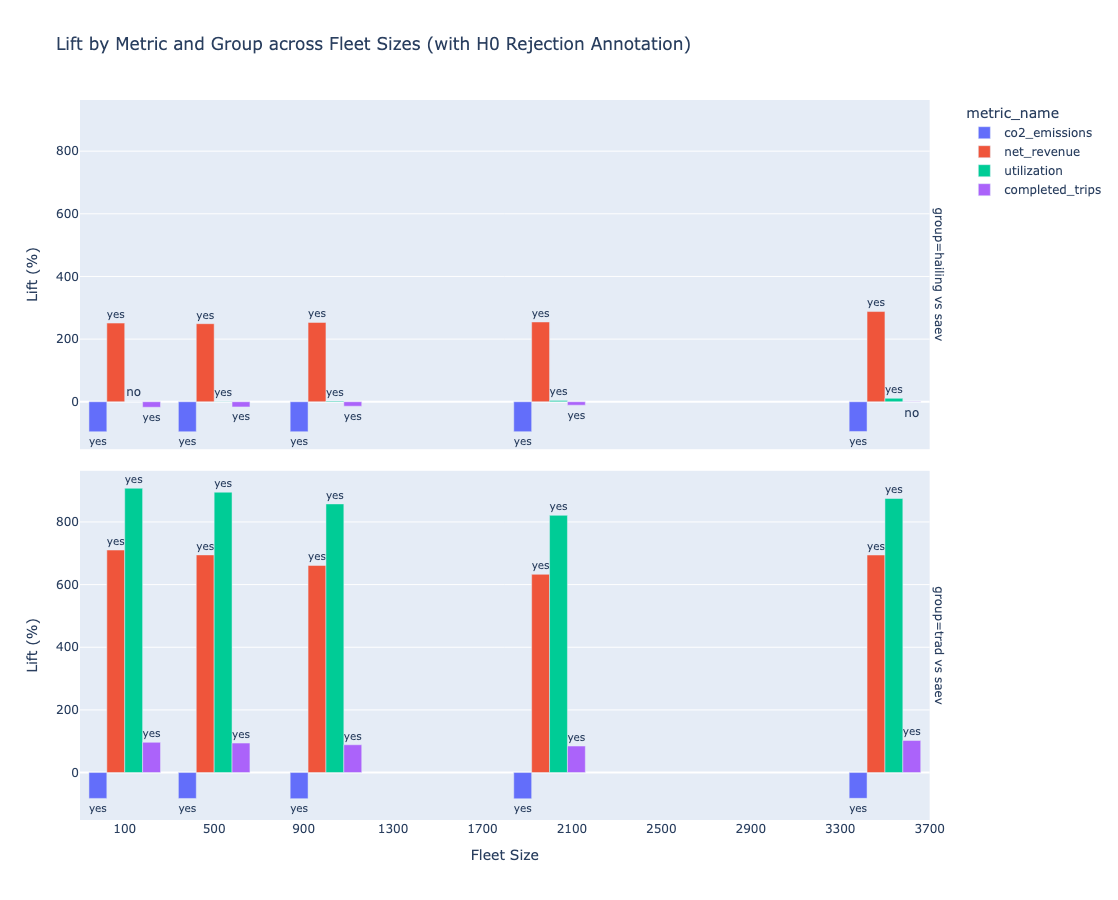

In [39]:
fig = px.bar(
    results,
    x='fleet_size',
    y='lift',
    color='metric_name',
    facet_row='group',
    barmode='group',
    text=results['is_reject'].apply(lambda x: 'yes' if x else 'no'),  # map True/False to yes/no
    labels={'fleet_size': 'Fleet Size', 'lift': 'Lift (%)'},
    title='Lift by Metric and Group across Fleet Sizes (with H0 Rejection Annotation)'
)

fig.update_traces(textposition='outside')
fig.update_layout(height=900, width=1100)
fig.show()




In [40]:
from itertools import product

fleet_sizes_trad = [100, 500, 1000, 2000, 3500]
fleet_sizes_saev = [100, 500, 1000, 2000, 3500]

results_diff_fleet = pd.DataFrame(
    columns=["metric_name", "group", "metric_value_left", "metric_value_right", "lift", "pval", "fleet_size_left", "fleet_size_right"]
)

for fs_trad, fs_saev in product(fleet_sizes_trad, fleet_sizes_saev):
    df_trad = df[(df['fleet_size'] == fs_trad) & (df['group'] == 'trad')]
    df_saev = df[(df['fleet_size'] == fs_saev) & (df['group'] == 'saev')]

    combined = pd.concat([df_trad, df_saev], axis=0)
    
    for metric, desc in metric_description.items():
        try:
            result = conduct_test(
                data=combined,
                nominator=desc['nominator'],
                metric_name=metric,
                combination=[('trad', 'saev')],
                tag_names=['trad', 'saev'],
                denominator=desc['denominator'],
                alpha=0.01
            )
            result['fleet_size_left'] = fs_trad
            result['fleet_size_right'] = fs_saev
            results_diff_fleet = pd.concat([results_diff_fleet, result], axis=0)
        except Exception as e:
            print(f"Error comparing trad({fs_trad}) vs saev({fs_saev}) for {metric}: {e}")


/Users/enbelodedova/Documents/diploma.simulation/analysis/../stattool/experiment_tool.py:74: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/var/folders/xs/_0l9xrzj3tz9bsyngdnyxmhr0000gn/T/ipykernel_9115/925174754.py:29: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/Users/enbelodedova/Documents/diploma.simulation/analysis/../stattool/experiment_tool.py:74: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer 

In [44]:
results_diff_fleet

,metric_name,group,metric_value_left,metric_value_right,lift,pval,fleet_size_left,fleet_size_right,is_reject
0,co2_emissions,trad vs saev,55.463503,46.923447,-15.397613,1.055253e-71,100,500,True
0,net_revenue,trad vs saev,23.292201,926.356048,3877.108181,0.000000e+00,100,500,True
0,utilization,trad vs saev,0.089855,0.887810,888.042668,0.000000e+00,100,500,True
0,completed_trips,trad vs saev,4.826514,45.942992,851.887730,0.000000e+00,100,500,True
0,co2_emissions,trad vs saev,55.463503,87.772963,58.253551,0.000000e+00,100,1000,True
...,...,...,...,...,...,...,...,...,...
0,completed_trips,trad vs saev,101.610855,86.836840,-14.539799,1.542113e-134,3500,1000,True
0,co2_emissions,trad vs saev,1128.076588,153.259169,-86.414117,0.000000e+00,3500,2000,True
0,net_revenue,trad vs saev,547.460248,3211.925574,486.695670,0.000000e+00,3500,2000,True
0,utilization,trad vs saev,0.056850,0.747454,1214.787665,0.000000e+00,3500,2000,True


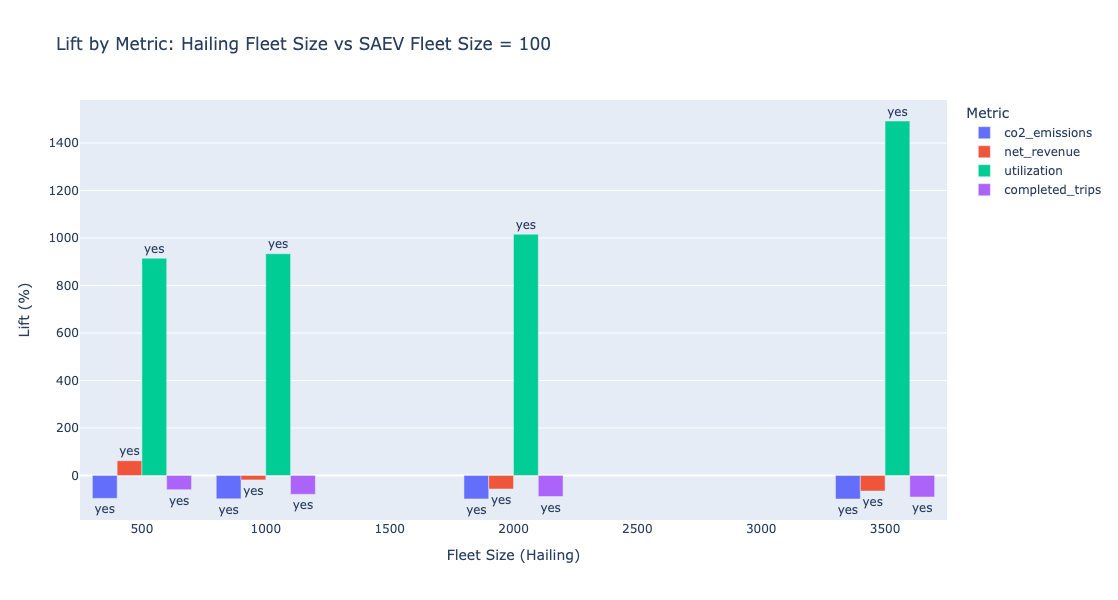

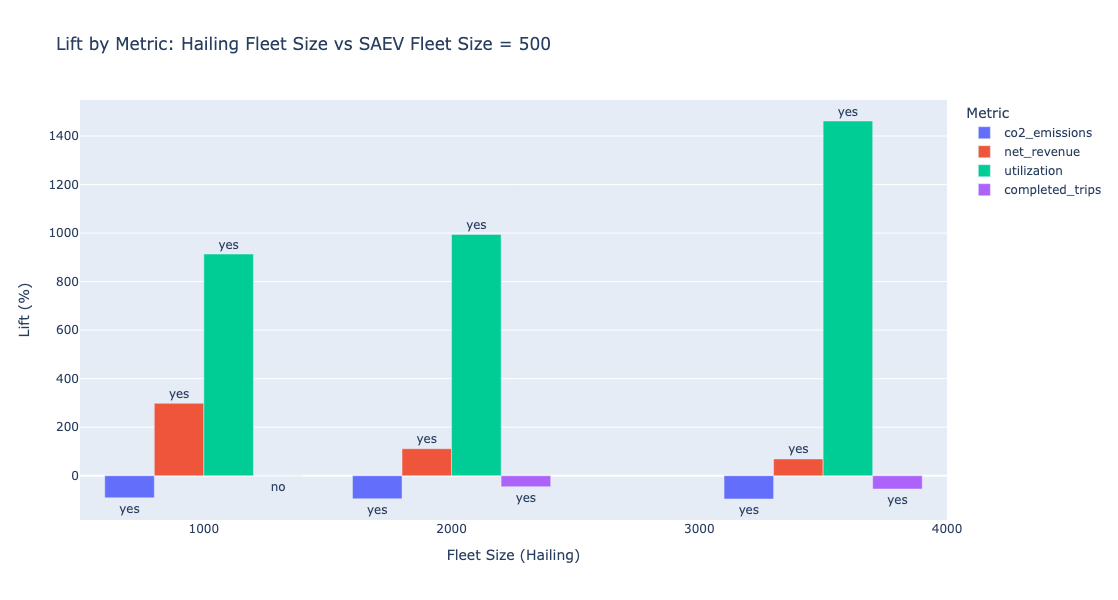

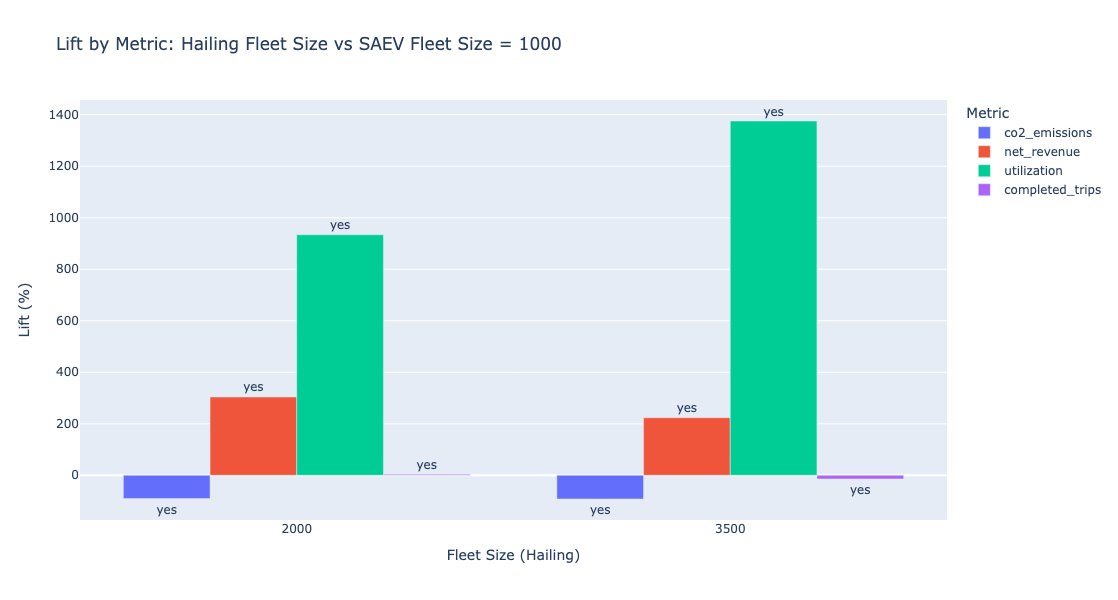

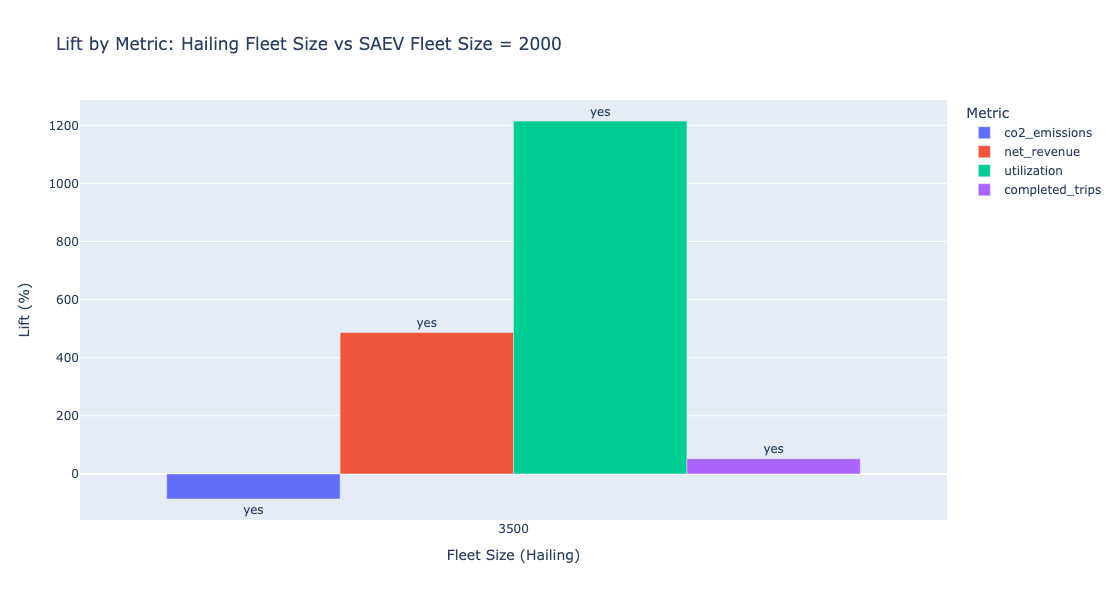

In [51]:
results_diff_fleet = results_diff_fleet[results_diff_fleet['fleet_size_left'] > results_diff_fleet['fleet_size_right']]

for fs_saev in sorted(results_diff_fleet['fleet_size_right'].unique()):
    subset = results_diff_fleet[results_diff_fleet['fleet_size_right'] == fs_saev]

    fig = px.bar(
        subset,
        x='fleet_size_left',
        y='lift',
        color='metric_name',
        barmode='group',
        text=subset['is_reject'].apply(lambda x: 'yes' if x else 'no'),
        labels={
            'fleet_size_left': 'Fleet Size (Hailing)',
            'lift': 'Lift (%)',
            'metric_name': 'Metric'
        },
        title=f'Lift by Metric: Hailing Fleet Size vs SAEV Fleet Size = {fs_saev}'
    )

    fig.update_traces(textposition='outside')
    fig.update_layout(height=600, width=900)
    fig.show()

